In [4]:
import pandas as pd
import numpy as np 

data = pd.read_csv("./DataSpline.csv")
data = data.drop(columns=["x(Wd,We)", "y(Wd,We)"])

data

,Unnamed: 0,Wd,We,"theta(Wd,We)"
0,0.00,1.612673,1.572300,0.003043
1,0.07,1.618553,1.578975,0.003270
2,0.14,1.624433,1.585649,0.003493
3,0.21,1.630313,1.592323,0.003712
4,0.28,1.636193,1.598998,0.003929
...,...,...,...,...
2141,149.87,-2.274523,-2.254289,-0.886088
2142,149.94,-2.274537,-2.254511,-0.889449
2143,150.01,-2.274551,-2.254732,-0.892844
2144,150.08,-2.274565,-2.254953,-0.896275


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Define predictors and target
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

# Scale our data to have mean 0
scaler = StandardScaler()
data[PREDICTORS] = scaler.fit_transform(data[PREDICTORS])

# Split into train (70%), validation (15%), and test (15%) sets
train_data, temp_data = train_test_split(data, test_size=0.3, shuffle=False)
valid_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=False)

# Convertendo para arrays numpy
train_x = train_data[PREDICTORS].to_numpy()
train_y = train_data[[TARGET]].to_numpy()

x_val = valid_data[PREDICTORS].to_numpy()
y_val = valid_data[[TARGET]].to_numpy()

x_test = test_data[PREDICTORS].to_numpy()
y_test = test_data[[TARGET]].to_numpy()


In [6]:
import matplotlib.pyplot as plt
import keras

def compile_model(model, epochs=100):
    # Compilando o modelo
    model.compile(loss="mse", optimizer="adam")

    # Treinando o modelo
    history = model.fit(train_x, train_y, epochs=epochs, validation_data=(x_val, y_val), verbose=False)

    # Avaliando o modelo
    mse_v = model.evaluate(x_val, y_val)
    print(f"Validation MSE: {mse_v:.4f}")
    
    mse_t = model.evaluate(x_test, y_test)
    print(f"Teste MSE: {mse_t:.4f}")

    # Plotando o histórico de treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()


2025-06-02 22:35:57.677014: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-02 22:35:58.325515: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-02 22:35:58.598926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748903759.013220   63846 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748903759.199533   63846 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748903760.038646   63846 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [7]:
model_RNA = keras.models.Sequential([
        keras.layers.Flatten(input_shape=[3, 1]),
        keras.layers.Dense(1)
])
model_RNN = keras.models.Sequential([
        keras.layers.SimpleRNN(1, input_shape=[3, 1])
])

complex_RNN = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[2, 1]),
        keras.layers.SimpleRNN(20, return_sequences=True),
        keras.layers.SimpleRNN(1)
])

complex_dense_RNN  = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[2, 1]),
        keras.layers.SimpleRNN(20),
        keras.layers.Dense(1)
])

simple_dense_RNN  = keras.models.Sequential([
        keras.layers.SimpleRNN(1, return_sequences=True, input_shape=[2, 1]),
        keras.layers.Dense(1)
])

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-06-02 22:36:09.683083: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4469 
Validation MSE: 0.8087
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5614 
Teste MSE: 1.6710


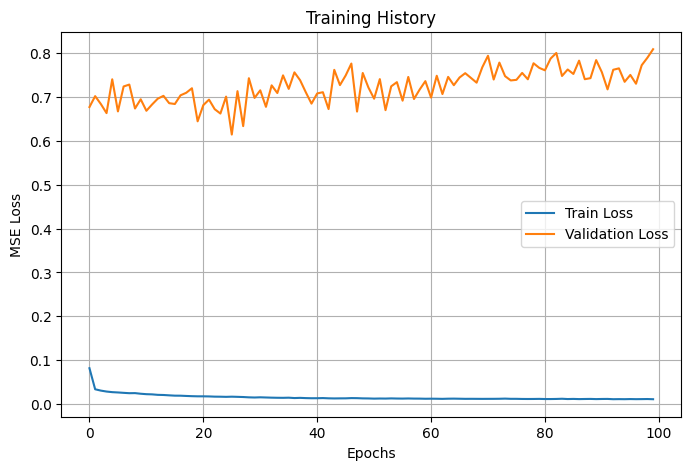

In [8]:
compile_model(complex_dense_RNN)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3732 
Validation MSE: 0.7021
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6624 
Teste MSE: 1.7692


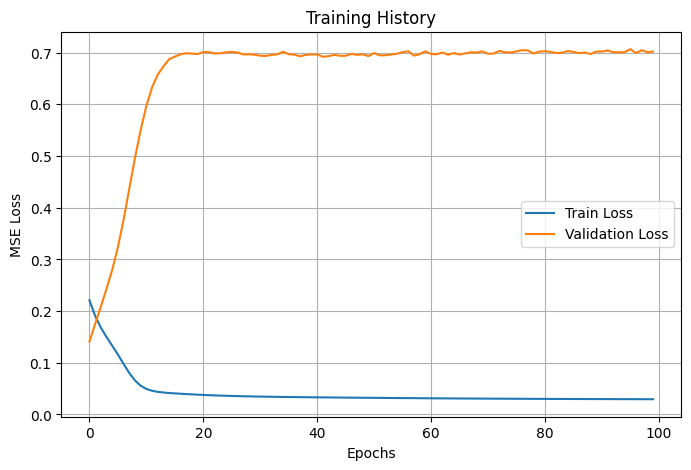

In [9]:
compile_model(simple_dense_RNN)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3831 
Validation MSE: 0.6932
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5698 
Teste MSE: 1.6724


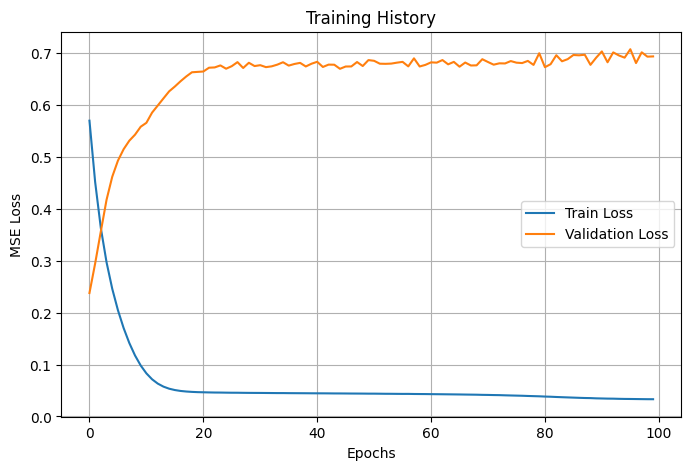

In [10]:
simple_dense_RNN  = keras.models.Sequential([
            keras.layers.SimpleRNN(2, return_sequences=True, input_shape=[3, 1]),
            keras.layers.Dense(1)
    ])
compile_model(simple_dense_RNN)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3791 
Validation MSE: 0.6999
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6116 
Teste MSE: 1.7159


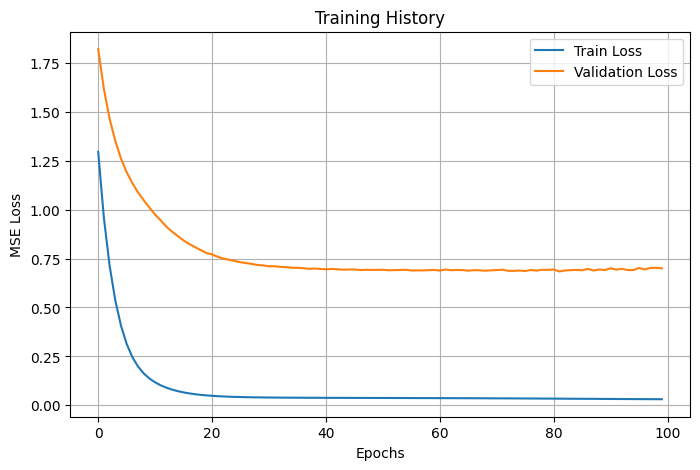

In [11]:
simple_dense_RNN  = keras.models.Sequential([
            keras.layers.SimpleRNN(3, return_sequences=True, input_shape=[3, 1]),
            keras.layers.Dense(1)
    ])
compile_model(simple_dense_RNN)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3868 
Validation MSE: 0.6909
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5188 
Teste MSE: 1.6261


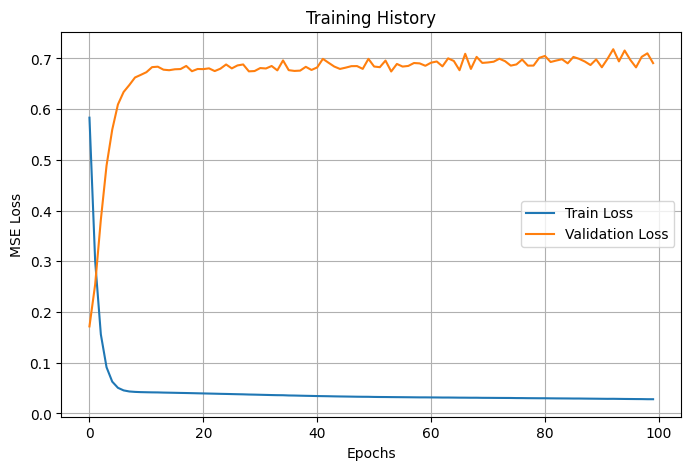

In [12]:
simple_dense_RNN  = keras.models.Sequential([
            keras.layers.SimpleRNN(4, return_sequences=True, input_shape=[3, 1]),
            keras.layers.Dense(1)
    ])
compile_model(simple_dense_RNN)